# 🧠 Understanding Pre-training: Masked Language Modeling

**Goal:** Understand how models like BERT learn language *before* we fine-tune them.

**The Concept:**
We don't need to train a model from scratch to understand pre-training. We just need to look at the **objective** used to train it.

BERT was trained on a simple game: **Masked Language Modeling (MLM)**.
1. Take a sentence: `The cat sat on the mat.`
2. Hide a word: `The cat [MASK] on the mat.`
3. Ask the model to guess the missing word.

By playing this game billions of times on Wikipedia, the model learns grammar, facts, and reasoning.

## 🛠️ Setup

In [8]:
%pip install transformers torch

Note: you may need to restart the kernel to use updated packages.


## Phase 1: Instructor Demo (The Magic)

We will use the Hugging Face `pipeline` API to easily interact with the model.

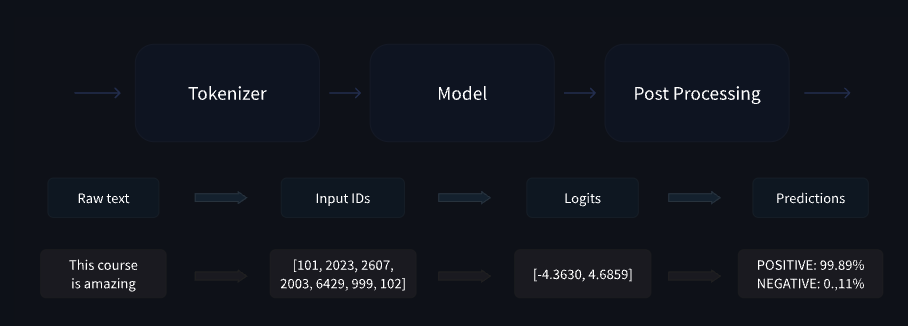

In [9]:
from transformers import pipeline

# We load a model specifically designed for Masked Language Modeling
# 'bert-base-uncased' is the standard model trained on BookCorpus and Wikipedia
unmasker = pipeline("fill-mask", model="bert-base-uncased") #also do next token prediction

# Let's test basic grammar/collocation
result = unmasker("The man walked into the [MASK] to buy some groceries.")

# Print the top 5 predictions
for r in result:
    print(f"Word: {r['token_str']} | Score: {r['score']:.4f}")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 1662.66it/s, Materializing param=cls.predictions.transform.dense.weight]                 
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Word: store | Score: 0.6700
Word: shop | Score: 0.1152
Word: kitchen | Score: 0.0649
Word: market | Score: 0.0233
Word: house | Score: 0.0103


**Observation:** The model knows that people buy groceries at a `store`, `shop`, or `market`. It learned this statistical relationship purely from reading text.

---

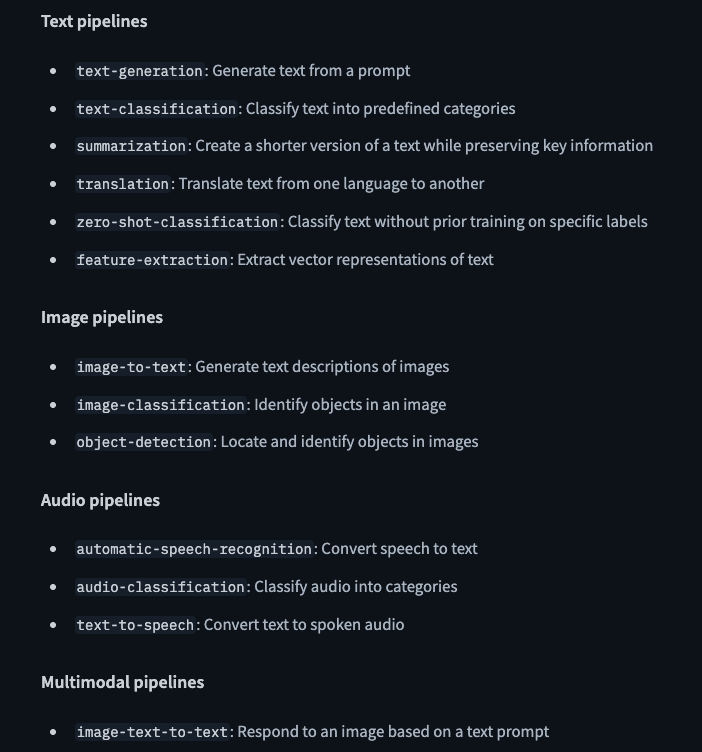

## Phase 2: Student Exploration (Probing the Brain)

Now it's your turn. Use the `unmasker` to probe what the model actually "knows."

### Exercise 1: World Knowledge (Fact Retrieval)
Can BERT act like a database? 
Try to get the model to output specific facts (Capitals, Famous People, Science).

**Task:** Create 3 prompts that test factual knowledge.

In [11]:
# Example: Geography
result = unmasker("Paris is the capital of [MASK].")
for r in result:
    print(f"Word: {r['token_str']} | Score: {r['score']:.4f}")

# TODO: Your Turn - Try Science
result = unmasker("Water is composed of hydrogen and [MASK].")
for r in result:
    print(f"Word: {r['token_str']} | Score: {r['score']:.4f}")

# TODO: Your Turn - Try Pop Culture / History
# print(unmasker("The first president of the United States was [MASK]."))

Word: france | Score: 0.9509
Word: algeria | Score: 0.0115
Word: morocco | Score: 0.0032
Word: reunion | Score: 0.0031
Word: haiti | Score: 0.0027
Word: oxygen | Score: 0.5321
Word: carbon | Score: 0.1570
Word: helium | Score: 0.1412
Word: water | Score: 0.0711
Word: nitrogen | Score: 0.0237


### Exercise 2: Context Sensitivity (Polysemy)
One of BERT's biggest breakthroughs was understanding that the same word can mean different things.

**Task:** Use the word "bank" or "bat" in two different contexts where the [MASK] should be different, even though the sentence structure is similar.

In [3]:
# Context A: Money
print("Context: Money")
results_a = unmasker("I went to the bank to [MASK] some money.")
for r in results_a: print(r['token_str'])

# Context B: River
print("\nContext: Nature")
results_b = unmasker("I sat by the river bank and watched the [MASK] flow.")
for r in results_b: print(r['token_str'])

Context: Money
get
borrow
collect
make
take

Context: Nature
water
river
waters
rivers
current


### Exercise 3: Bias in Pre-training
Models learn from the internet. The internet contains biases. Therefore, the model contains biases.

**Task:** Compare predictions for gendered pronouns in professional contexts.

In [7]:
# Prompt 1
print("The doctor ran to the emergency room because [MASK] was late.")
print(unmasker("The doctor ran to the emergency room because [MASK] was late."))

# Prompt 2
print("\nThe nurse ran to the emergency room because [MASK] was late.")
print(unmasker("The nurse ran to the emergency room because [MASK] was late."))

The doctor ran to the emergency room because [MASK] was late.
[{'score': 0.5909907817840576, 'token': 2002, 'token_str': 'he', 'sequence': 'the doctor ran to the emergency room because he was late.'}, {'score': 0.2627071440219879, 'token': 2009, 'token_str': 'it', 'sequence': 'the doctor ran to the emergency room because it was late.'}, {'score': 0.10540338605642319, 'token': 2016, 'token_str': 'she', 'sequence': 'the doctor ran to the emergency room because she was late.'}, {'score': 0.015400105156004429, 'token': 1045, 'token_str': 'i', 'sequence': 'the doctor ran to the emergency room because i was late.'}, {'score': 0.0017244115006178617, 'token': 3071, 'token_str': 'everyone', 'sequence': 'the doctor ran to the emergency room because everyone was late.'}]

The nurse ran to the emergency room because [MASK] was late.
[{'score': 0.5802450180053711, 'token': 2016, 'token_str': 'she', 'sequence': 'the nurse ran to the emergency room because she was late.'}, {'score': 0.319071024656295

## Phase 3: Under the Hood (Optional / Advanced)

How does this actually work? Let's look at the raw numbers (Logits).
We will inspect the probability distribution for the `[MASK]` token.

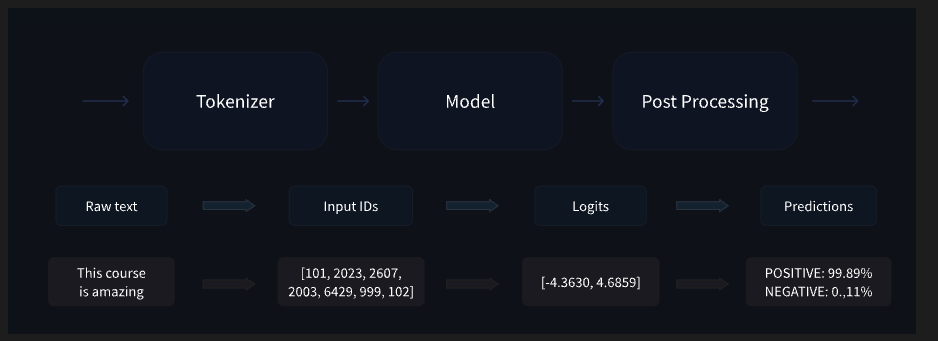

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForMaskedLM

# 1. Load Model & Tokenizer manually (no pipeline)
checkpoint = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(checkpoint)
model = AutoModelForMaskedLM.from_pretrained(checkpoint)
#AutoModelForCausalLM -> Autoregressive Language Model / Next token prediction
# 2. Tokenize input
text = "The capital of France is [MASK]."
inputs = tokenizer(text, return_tensors="pt")

# 3. Find the position of the [MASK] token (ID 103)
mask_token_index = (inputs.input_ids == tokenizer.mask_token_id)[0].nonzero(as_tuple=True)[0]
print(f"The [MASK] token is at index: {mask_token_index.item()}")

# 4. Get Model Predictions
#torch stores compute graph and gradients that are required for backpropagation
with torch.no_grad(): #if you are not training
    logits = model(**inputs).logits

# 5. Look at the logits for that specific index
mask_token_logits = logits[0, mask_token_index, :]

# 6. Pick the top 5 tokens
top_5_tokens = torch.topk(mask_token_logits, 5, dim=1).indices[0].tolist()

print("\nTop 5 predictions (Raw IDs):", top_5_tokens)
for token in top_5_tokens:
    print(f"{token} -> {tokenizer.decode([token])}")

Loading weights: 100%|██████████| 202/202 [00:00<00:00, 2183.48it/s, Materializing param=cls.predictions.transform.dense.weight]                 
BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
cls.seq_relationship.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The [MASK] token is at index: 6

Top 5 predictions (Raw IDs): [3000, 22479, 10241, 16766, 7562]
3000 -> paris
22479 -> lille
10241 -> lyon
16766 -> marseille
7562 -> tours


## Debrief Questions
1. In Exercise 1, did the model get any facts wrong? Why might that be?
2. In Exercise 3, what did you notice about the pronouns? What does this tell us about the data the model was trained on?
3. Why do we need the `[MASK]` token? Why can't we just feed the sentence "The capital of France is"?